## Imports

In [4]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [5]:
wine_data = pd.read_csv('../winequality-white.csv', sep=';')
wine_feat = wine_data.iloc[:, :-1]
wine_target = wine_data.iloc[:, -1]

In [6]:
wine_target

0       6
1       6
2       6
3       6
4       6
       ..
4893    6
4894    5
4895    6
4896    7
4897    6
Name: quality, Length: 4898, dtype: int64

## Descrição preliminar dos dados

O conjunto de dados consiste em **N = 4897** amostras do vinho branco português, chamado "Vinho Verde". A fonte original do dataset inclui amostras de vinhos branco e vermelho, entretanto, como essa variação de tipo pode afetar nos gostos e, portanto, nos resultados preditos, optamos por limitar para aquele do qual temos mais amostras, a saber, o vinho branco. Para a garantia de qualidade e segurança da saúde humana, a indústria de vinhos submete seus produtos a testes fisicoquímicos em laboratório, incluindo a medição de valores como pH ou densidade da bebida, além dos valores melhor detalhados abaixo.

O dataset contém as seguintes informações:
-  Fixed acidity: Concentração de ácido tártaro (g/dm³)
-  Volatile acidity: Concentração de ácido acético (g/dm³)
-  Citric acid: Concentração de ácido cítrico (g/dm³)
-  Residual sugar: Concentração de açúcar residual (g/dm³)
-  Chlorides: Concentração de cloreto de sódio (g/dm³)
-  Free sulfur dioxide: Concentração de dióxido de enxofre livre (mg/dm³)
-  Total sulfur dioxide: Concentração total de dióxido de enxofre (mg/dm³)
-  Density: Densidade do vinho (g/dm³)
-  pH
-  Sulphates: Concentração de sulfato de potássio (g/dm³)
-  Alcohol: Volume de álcool (vol.%)
-  Quality: Qualidade do vinho (classificação inteira entre 0 e 10)

Realizando uma simples análise do conjunto de dados, considerando que desejamos inferir a qualidade de um certo vinho dadas as suas medições laboratoriais, temos que o dataset possui **D = 11** variáveis preditoras, a saber, medições químicas de laboratório, e **L = 11** classes, que são as diferentes classificações do vinho quanto à sua qualidade, que pode variar entre 0 e 10. Posteriormente, analisaremos a distribuição entre classes.

In [7]:
N = wine_data.shape[0]
D = wine_feat.shape[1]
L = 11

<Axes: title={'center': 'Distribuição de classes de vinho branco'}, xlabel='Qualidade do vinho', ylabel='Número de amostras'>

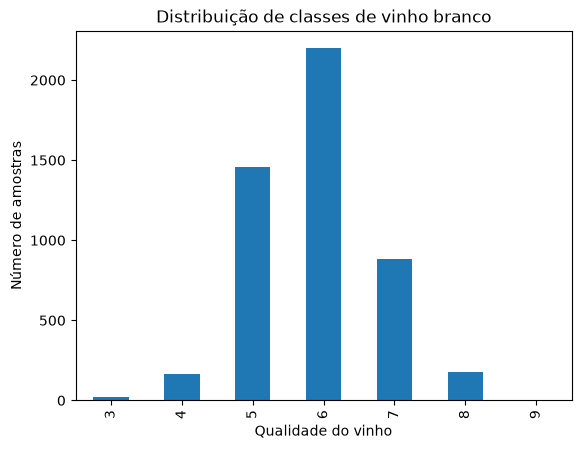

In [8]:
class_distrib = wine_target.value_counts()
class_distrib
class_distrib.sort_index(inplace=True)
class_distrib.plot(kind='bar', title='Distribuição de classes de vinho branco', xlabel='Qualidade do vinho', ylabel='Número de amostras')

Vemos, no resultado acima, uma distribuição equilibrada entre as classes de vinho, concentrando-se em valores médios, enquanto valores extremos (baixos e altos) são escassos. Nota-se que essa distribuição aproxima-se de uma distribuição normal.

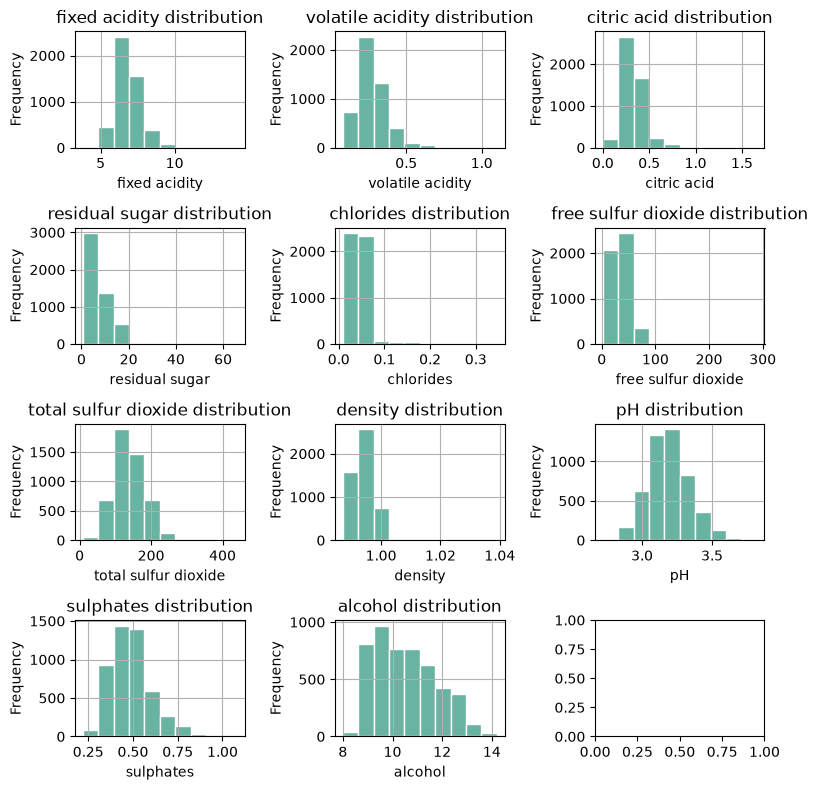

In [9]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(8, 8))

# Flatten the axes array (makes it easier to iterate over)
axes = axes.flatten()

# Loop through each column and plot a histogram
for i, column in enumerate(wine_feat.columns):
    
    # Add the histogram
    wine_feat[column].hist(ax=axes[i], # Define on which ax we're working on
                    edgecolor='white', # Color of the border
                    color='#69b3a2' # Color of the bins
                   )
    
    # Add title and axis label
    axes[i].set_title(f'{column} distribution') 
    axes[i].set_xlabel(column) 
    axes[i].set_ylabel('Frequency') 

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Análise Univariada Condicional à Classe

Fazer uma análise univariada condicional à classe é essencial para avaliar o poder preditivo individual de cada variável e entender a separabilidade entre as categorias antes de treinar modelos complexos. Essa etapa permite identificar quais atributos discriminam melhor os dados, detectar sobreposições problemáticas e localizar outliers específicos. Nela, analisamos o preditor de forma isolada, mas separamos os dados de acordo com sua classe, ou seja, analisamos as medições químicas separadamente, porém, considerando os diferentes níveis de qualidade do vinho.